# NDT Analysis

Investigates whether non-decision time (NDT) is consistent per subject across SNR conditions.

For each subject, the congruence-vs-lag profile is computed separately for each block (1–6).
Blocks 1–3 use one SNR level; blocks 4–6 use a different SNR level.
If NDT is a stable sensorimotor property, the peak congruence lag should be the same
across blocks and SNR conditions within a subject.

**Block pairs compared:** 1 vs 4, 2 vs 5, 3 vs 6.

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sys.path.insert(0, os.path.dirname(os.getcwd()))
from pigeon.data import get_data_table, get_bounds

MAX_NDT = 5
LAGS    = np.arange(MAX_NDT)

In [2]:
# Load OL data keeping original block numbering (1–6)
data = get_data_table(task_type='OL', combine_snr=False, correct_bias=None)

subjects = sorted(data['subject_index'].dropna().unique())
blocks   = sorted(data['block_index'].dropna().unique().astype(int))

print(f'{len(subjects)} subjects')
print(f'Blocks present: {blocks}')
print(f'Trials total:   {len(data):,}')

# Show SNR per block (should be one value per block in blocked design)
for b in blocks:
    snrs = data.loc[data['block_index'] == b, 'snr'].dropna().unique()
    print(f'  Block {b}: SNR = {np.round(snrs, 3)}')

  1: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_14h39.24.096.csv
  2: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_15h37.48.260.csv
  3: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h34.46.761.csv
  4: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h35.25.285.csv
  5: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.33.669.csv
  6: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.41.364.csv
  7: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.49.086.csv
  8: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pi

In [3]:
# Compute per-block congruence profiles for each subject.
# cong_data[subj][block] = dict with 'cong' (MAX_NDT,) and 'snr' (float)

MIN_TRIALS = 15   # skip block if too few trials

cong_data = {subj: {} for subj in subjects}

for subj in subjects:
    subj_data = data[data['subject_index'] == subj]
    for block in blocks:
        bd = subj_data[subj_data['block_index'] == block]
        # keep trials with valid steps, choices, and RT > 2
        bd = bd[bd['steps'].apply(lambda s: s is not None and len(s) > 0)]
        bd = bd[np.isfinite(bd['choice'])]
        bd = bd[bd['RT'] > 2]
        if len(bd) < MIN_TRIALS:
            continue

        steps_list = list(bd['steps'])
        choices    = bd['choice'].values.astype(float)
        snr_val    = float(np.nanmedian(bd['snr']))

        try:
            _, _, _, cong, _ = get_bounds(
                steps_list, choices,
                max_ndt=MAX_NDT,
                rt_cutoff_threshold=None,   # no RT filter — want full profile
            )
            # cong shape: (MAX_NDT, n_snrs); single block → n_snrs=1
            cong_data[subj][block] = {
                'cong': cong[:, 0],
                'snr':  snr_val,
                'n':    len(bd),
            }
        except Exception as exc:
            print(f'  S{subj} B{block}: {exc}')

n_complete = sum(
    1 for s in subjects
    if all(b in cong_data[s] for b in [1,2,3,4,5,6])
)
print(f'Done. {n_complete}/{len(subjects)} subjects have all 6 blocks.')

Done. 52/60 subjects have all 6 blocks.


/var/folders/tp/dghl0fxd0wg0rsyq4p4tzcnc0000gn/T/ipykernel_69709/2545784996.py:41: RuntimeWarning: Mean of empty slice
  mean_norm = np.nanmean(subj_norm, axis=0)


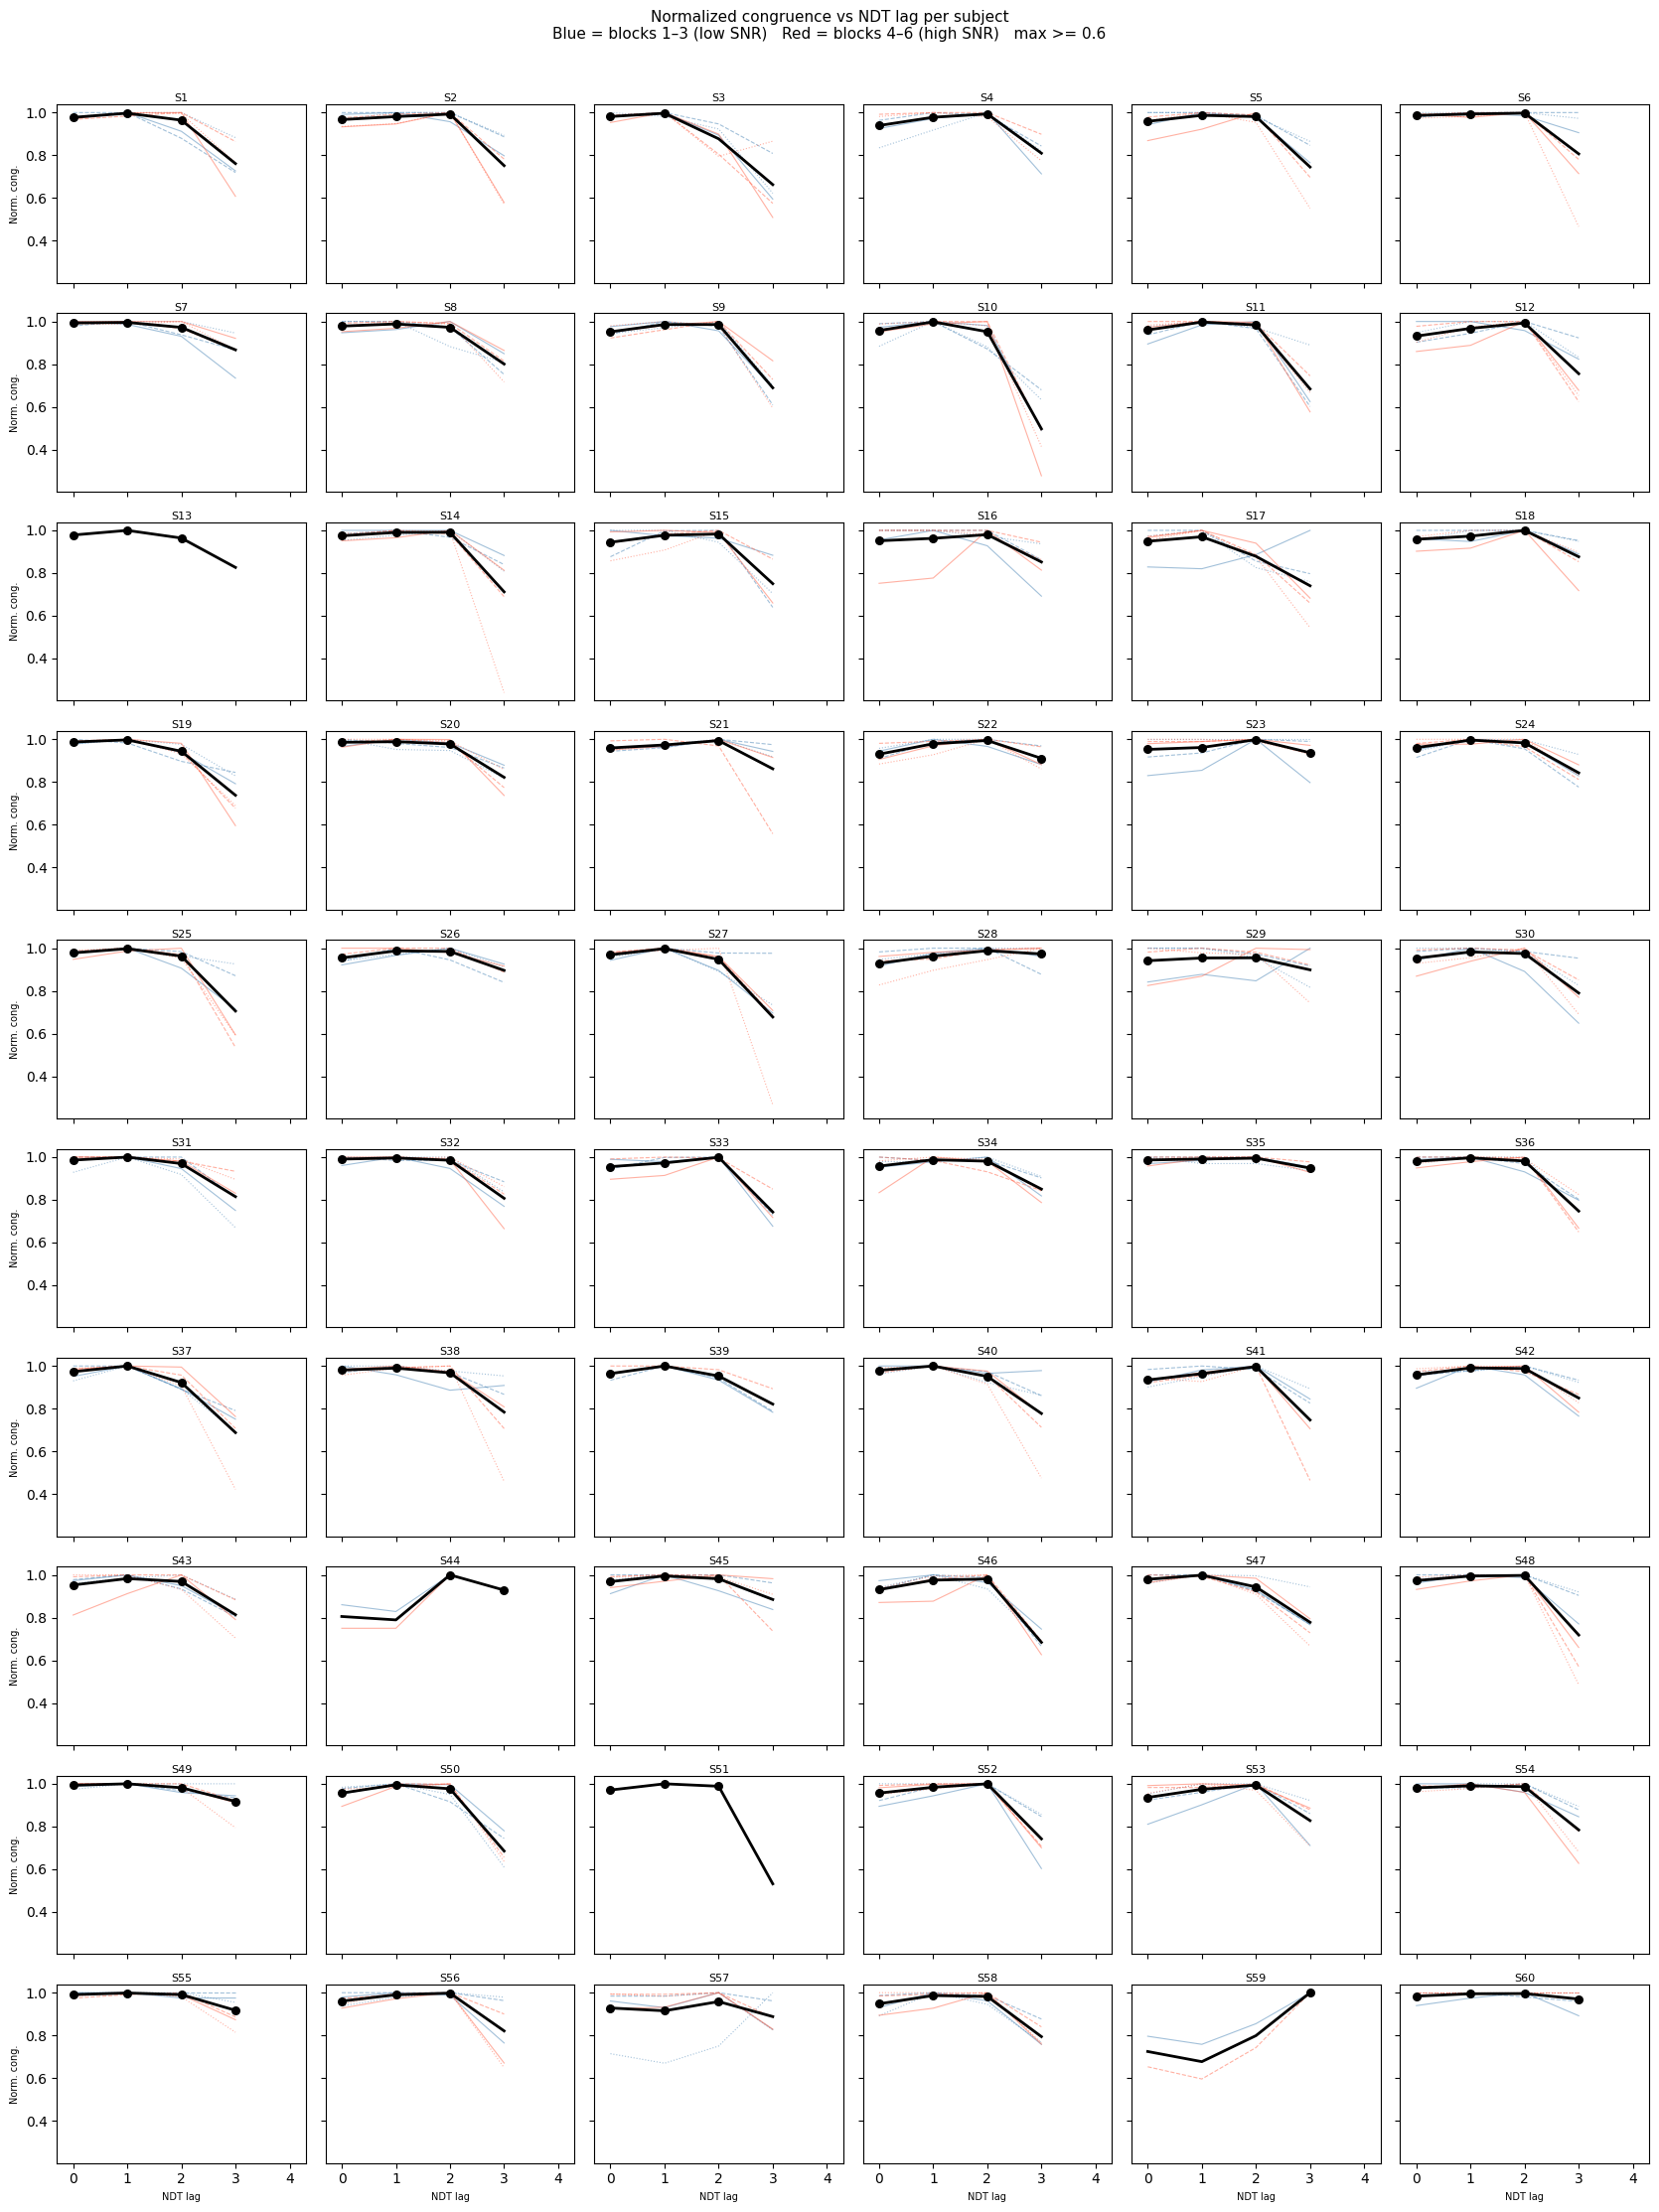

In [4]:
# ── Normalized congruence profiles per subject (max-normalized, max >= 0.6) ──
# Blue = blocks 1-3 (low SNR), Red = blocks 4-6 (high SNR)
# Each curve is normalized to its own max; cases where max < 0.6 are excluded.
# Thick black line = mean of included curves for that subject.
# Black dots = points on mean curve with normalized congruence > 0.9.

STYLE = {
    1: dict(color='steelblue',   ls='-',  lw=0.8, alpha=0.5),
    2: dict(color='steelblue',   ls='--', lw=0.8, alpha=0.5),
    3: dict(color='steelblue',   ls=':',  lw=0.8, alpha=0.5),
    4: dict(color='tomato',      ls='-',  lw=0.8, alpha=0.5),
    5: dict(color='tomato',      ls='--', lw=0.8, alpha=0.5),
    6: dict(color='tomato',      ls=':',  lw=0.8, alpha=0.5),
}

N_COLS = 6
N_ROWS = int(np.ceil(len(subjects) / N_COLS))

fig, axs = plt.subplots(N_ROWS, N_COLS,
                         figsize=(2.8 * N_COLS, 2.2 * N_ROWS),
                         sharex=True, sharey=True)
axs = axs.flatten()

for si, subj in enumerate(subjects):
    ax = axs[si]
    subj_norm = []
    for block in blocks:
        if block not in cong_data[subj]:
            continue
        cong = cong_data[subj][block]['cong'].astype(float)
        if np.all(np.isnan(cong)):
            continue
        cmax = np.nanmax(cong)
        if cmax < 0.6:
            continue
        norm = cong / cmax
        ax.plot(LAGS, norm, **STYLE[block])
        subj_norm.append(norm)

    if subj_norm:
        mean_norm = np.nanmean(subj_norm, axis=0)
        ax.plot(LAGS, mean_norm, color='black', lw=2.0, zorder=5)
        # Add points where normalized congruence > 0.9
        high_mask = mean_norm > 0.9
        if np.any(high_mask):
            ax.scatter(LAGS[high_mask], mean_norm[high_mask],
                       color='black', s=30, zorder=6)

    ax.set_xlim(-0.3, MAX_NDT - 0.7)
    ax.set_xticks(LAGS)
    ax.set_title(f'S{int(subj)}', fontsize=8, pad=2)
    if si % N_COLS == 0:
        ax.set_ylabel('Norm. cong.', fontsize=7)
    if si >= (N_ROWS - 1) * N_COLS:
        ax.set_xlabel('NDT lag', fontsize=7)

for si in range(len(subjects), len(axs)):
    axs[si].axis('off')

fig.suptitle(
    'Normalized congruence vs NDT lag per subject\n'
    'Blue = blocks 1–3 (low SNR)   Red = blocks 4–6 (high SNR)   max >= 0.6',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()


In [ ]:
# ── Block-pair comparison plots ───────────────────────────────────────────────
# For each pair (1v4, 2v5, 3v6): overlay congruence profiles from both blocks
# per subject, and show scatter of peak lags.
# Filled dots on mean curves = points where normalized congruence > 0.9.

BLOCK_PAIRS = [(1, 4), (2, 5), (3, 6)]

fig, axs = plt.subplots(2, 3, figsize=(13, 8))

# Top row: overlay congruence profiles for all subjects per block pair
for pi, (b_lo, b_hi) in enumerate(BLOCK_PAIRS):
    ax = axs[0, pi]
    for subj in subjects:
        if b_lo not in cong_data[subj] or b_hi not in cong_data[subj]:
            continue
        clo = cong_data[subj][b_lo]['cong']
        chi = cong_data[subj][b_hi]['cong']
        ax.plot(LAGS, clo, color='steelblue', lw=0.6, alpha=0.35)
        ax.plot(LAGS, chi, color='tomato',    lw=0.6, alpha=0.35)

    # Mean across subjects
    clo_all = np.array([cong_data[s][b_lo]['cong'] for s in subjects if b_lo in cong_data[s]])
    chi_all = np.array([cong_data[s][b_hi]['cong'] for s in subjects if b_hi in cong_data[s]])
    if len(clo_all):
        mean_lo = np.nanmean(clo_all, axis=0)
        ax.plot(LAGS, mean_lo, color='steelblue', lw=2.5, label=f'B{b_lo} mean')
        lo_max = np.nanmax(mean_lo)
        if lo_max > 0:
            high_mask = (mean_lo / lo_max) > 0.9
            if np.any(high_mask):
                ax.scatter(LAGS[high_mask], mean_lo[high_mask],
                           color='steelblue', s=50, zorder=6)
    if len(chi_all):
        mean_hi = np.nanmean(chi_all, axis=0)
        ax.plot(LAGS, mean_hi, color='tomato', lw=2.5, label=f'B{b_hi} mean')
        hi_max = np.nanmax(mean_hi)
        if hi_max > 0:
            high_mask = (mean_hi / hi_max) > 0.9
            if np.any(high_mask):
                ax.scatter(LAGS[high_mask], mean_hi[high_mask],
                           color='tomato', s=50, zorder=6)

    ax.axhline(0.5, color='gray', lw=0.5, ls=':')
    ax.set_xlim(-0.3, MAX_NDT - 0.7)
    ax.set_ylim(0.42, 1.02)
    ax.set_xticks(LAGS)
    ax.set_title(f'Blocks {b_lo} vs {b_hi}', fontsize=10)
    ax.set_xlabel('NDT lag', fontsize=9)
    ax.set_ylabel('Congruence', fontsize=9)
    ax.legend(fontsize=8)

# Bottom row: scatter of peak lag (low-SNR block) vs peak lag (high-SNR block)
for pi, (b_lo, b_hi) in enumerate(BLOCK_PAIRS):
    ax = axs[1, pi]
    peak_lo, peak_hi = [], []
    for subj in subjects:
        if b_lo not in cong_data[subj] or b_hi not in cong_data[subj]:
            continue
        clo = cong_data[subj][b_lo]['cong']
        chi = cong_data[subj][b_hi]['cong']
        if np.all(np.isnan(clo)) or np.all(np.isnan(chi)):
            continue
        peak_lo.append(int(np.nanargmax(clo)))
        peak_hi.append(int(np.nanargmax(chi)))

    if peak_lo:
        # Same jitter offset for x and y so paired points stay coherent diagonally
        jitter = np.random.default_rng(0).uniform(-0.15, 0.15, len(peak_lo))
        jlo = np.array(peak_lo) + jitter
        jhi = np.array(peak_hi) + jitter
        ax.scatter(jlo, jhi, s=25, alpha=0.5, color='purple')

        agree = np.mean(np.array(peak_lo) == np.array(peak_hi))
        ax.text(0.05, 0.95, f'Agreement: {agree:.0%}\n(n={len(peak_lo)})',
                transform=ax.transAxes, fontsize=8, va='top')

    ax.plot([-0.5, MAX_NDT - 0.5], [-0.5, MAX_NDT - 0.5], 'k:', lw=1)
    ax.set_xlim(-0.5, MAX_NDT - 0.5)
    ax.set_ylim(-0.5, MAX_NDT - 0.5)
    ax.set_xticks(LAGS); ax.set_yticks(LAGS)
    ax.set_xlabel(f'Peak lag, block {b_lo} (low SNR)', fontsize=9)
    ax.set_ylabel(f'Peak lag, block {b_hi} (high SNR)', fontsize=9)
    ax.set_aspect('equal')

fig.suptitle('Block-pair NDT comparison (OL data)', fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
# ── Summary: peak lag distribution and within-subject consistency ─────────────

print('Peak NDT lag distribution per block:')
print(f'{"Block":>7}  {"SNR":>6}  {"n":>5}  Peak lag counts (lag 0..4)')
print('-' * 55)
for block in blocks:
    peaks = []
    snrs  = []
    for subj in subjects:
        if block not in cong_data[subj]:
            continue
        cong = cong_data[subj][block]['cong']
        if np.all(np.isnan(cong)):
            continue
        peaks.append(int(np.nanargmax(cong)))
        snrs.append(cong_data[subj][block]['snr'])
    counts = np.bincount(peaks, minlength=MAX_NDT)
    snr_med = np.median(snrs) if snrs else np.nan
    print(f'{block:>7}  {snr_med:>6.2f}  {len(peaks):>5}  {counts}')

print()
print('Within-subject peak-lag consistency across all 6 blocks:')
all_same, majority_same = 0, 0
for subj in subjects:
    peaks = [int(np.nanargmax(cong_data[subj][b]['cong']))
             for b in blocks if b in cong_data[subj]
             and not np.all(np.isnan(cong_data[subj][b]['cong']))]
    if len(peaks) < 2:
        continue
    mode_count = max(np.bincount(peaks))
    if mode_count == len(peaks):
        all_same += 1
    if mode_count >= len(peaks) / 2:
        majority_same += 1

n_valid = sum(1 for s in subjects if sum(b in cong_data[s] for b in blocks) >= 2)
print(f'  All 6 blocks agree:       {all_same}/{n_valid} ({100*all_same/n_valid:.0f}%)')
print(f'  Majority (≥3/6) agree:    {majority_same}/{n_valid} ({100*majority_same/n_valid:.0f}%)')

Peak NDT lag distribution per block:
  Block     SNR      n  Peak lag counts (lag 0..4)
-------------------------------------------------------
      1   -0.33     60  [ 8 31 18  3  0]
      2   -0.33     59  [23 25 11  0  0]
      3   -0.33     56  [18 26 11  1  0]
      4    0.00     55  [ 5 15 34  1  0]
      5    1.00     59  [11 29 17  2  0]
      6    1.00     55  [11 26 17  1  0]

Within-subject peak-lag consistency across all 6 blocks:
  All 6 blocks agree:       1/60 (2%)
  Majority (≥3/6) agree:    55/60 (92%)
